# **Exploratory Data Analysis for Payment & Shipping**
####  subtitle 

## Table of Contents

- [0. EDA for ](#topic-0)
- [1. Import Libraries](#topic-1)
- [2. Import Data](#topic-2)
- [3. Analysis Section](#topic-3)
  - [3.1 ](#topic-3-1)
  - [3.2 ](#topic-3-2)
  - [3.3 ](#topic-3-3)
  - [3.4 ](#topic-3-4)
  - [3.5 ](#topic-3-5)
- [4. Conclusion & Insights Recap](#topic-4)
- [5. Recommendations based on Insights](#topic-5)


## **0. EDA for Payments & Shipping Summary** <a id="topic-0"></a>

***Will change this accordingly when finished***
- Product Category Landscape: Explore the distribution of product categories, identify dominant ones, and assess balance across the catalog.
- Product Weight & Volume Patterns: Analyze product size and weight trends to understand shipping and storage implications across categories.
- Seller Distribution & Activity: Examine how orders are distributed across sellers, highlighting the role of individual vs. large-scale sellers.
- Product-Seller Relationships: Understand how many sellers sell a product and how many products a seller lists to assess competition and specialization.
- Top Seller Performance: Identify the top-performing sellers based on both order volume and revenue to reveal market concentration.
- Operational & Strategic Insights: Extract meaningful patterns about inventory diversity, logistics needs, and seller dynamics to guide platform decisions.

## **1. Import Libraries** <a id="topic-1"></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## **2. Import Data** <a id="topic-2"></a>

In [3]:
date_cols = ["order_purchase_timestamp", "order_approved_at", "order_delivered_timestamp", "order_estimated_delivery_date"]

orders = pd.read_csv('../data/processed/orders.csv')
orders[date_cols] = orders[date_cols].apply(pd.to_datetime, errors='coerce')  # Safely parse all, fallback if weird values

orders["delivery_time_gap"] = pd.to_timedelta(orders["delivery_time_gap"], errors='coerce')

order_items = pd.read_csv('../data/processed/order_items.csv')
customers = pd.read_csv('../data/processed/customers.csv')
payments = pd.read_csv('../data/processed/payments.csv')
products = pd.read_csv('../data/processed/products.csv')

## **3. Analysis Section** <a id="topic-3"></a>
***alter with corresponding text when done***
- Data Exploration: This section dives deep into products and seller performance, categorical trends in products, and seller dynamics using statistical & visualization methods.
- Visual-Driven: Data is visualized through a variety of plots — bar plots, histograms, KDEs, line graphs — to surface hidden patterns and outliers.
- Contextual Commentary: Every insight is paired with interpretation to understand its potential business or logistic impact.
- Subsection-Focused: The section is divided into specific focus areas like product category, dimensions, sellers order distribution analysis etc.
- Real-World Takeaways: Each analysis aims to bring forward operational or strategic implications, making the data actionable.

In [4]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date,delivery_time_gap,delivery_time_gap_hrs,purchase_to_approval_hours,approval_to_delivery_hours,purchase_to_delivery_hours
0,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,13 days 01:40:08,313.668889,0.271944,99.094167,99.366111
1,v6px92oS8cLG,PxA7fv9spyhx,delivered,2018-06-20 21:40:31,2018-06-20 22:20:20,2018-07-03 22:51:22,2018-07-24,20 days 01:08:38,481.143889,0.663611,312.517222,313.180833
2,Ulpf9skrhjfm,g3nXeJkGI0Qw,delivered,2018-02-16 16:19:31,2018-02-17 16:15:35,2018-02-27 01:29:50,2018-03-08,8 days 22:30:10,214.502778,23.934444,225.237500,249.171944
3,bwJVWupf2keN,EOEsCQ6QlpIg,delivered,2018-08-18 18:04:29,2018-08-18 18:15:16,2018-08-27 20:03:51,2018-09-19,22 days 03:56:09,531.935833,0.179722,217.809722,217.989444
4,Dd0QnrMk9Cj5,mVz5LO2Vd6cL,delivered,2017-12-22 16:44:04,2017-12-22 17:31:31,2018-01-05 19:22:49,2018-01-18,12 days 04:37:11,292.619722,0.790833,337.855000,338.645833


In [6]:
products.head()

,product_id,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_volume_cm3,weight_volume_ratio
0,90K0C1fIyQUf,toys,491.0,19.0,12.0,16.0,3648.0,0.134594
1,qejhpMGGVcsl,watches_gifts,440.0,18.0,14.0,17.0,4284.0,0.102708
2,qUS5d2pEAyxJ,costruction_tools_garden,2200.0,16.0,16.0,16.0,4096.0,0.537109
3,639iGvMyv0De,toys,1450.0,68.0,3.0,48.0,9792.0,0.148080
4,1lycYGcsic2F,toys,300.0,17.0,4.0,12.0,816.0,0.367647


In [138]:
order_items.head()

,order_id,product_id,seller_id,price,shipping_charges,shipping_price_ratio
0,Axfy13Hk4PIk,90K0C1fIyQUf,ZWM05J9LcBSF,223.51,84.65,0.378730
1,v6px92oS8cLG,qejhpMGGVcsl,IjlpYfhUbRQs,170.80,23.79,0.139286
2,Ulpf9skrhjfm,qUS5d2pEAyxJ,77p2EYxcM9MD,64.40,17.38,0.269876
3,bwJVWupf2keN,639iGvMyv0De,jWzS0ayv9TGf,264.50,30.72,0.116144
4,Dd0QnrMk9Cj5,1lycYGcsic2F,l1pYW6GBnPMr,779.90,30.66,0.039313


In [8]:
customers.head()

,customer_id,customer_zip_code_prefix,customer_city,customer_state
0,hCT0x9JiGXBQ,58125,varzea paulista,SP
1,PxA7fv9spyhx,3112,armacao dos buzios,RJ
2,g3nXeJkGI0Qw,4119,jandira,SP
3,EOEsCQ6QlpIg,18212,uberlandia,MG
4,mVz5LO2Vd6cL,88868,ilhabela,SP


In [9]:
products.head()

,product_id,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_volume_cm3,weight_volume_ratio
0,90K0C1fIyQUf,toys,491.0,19.0,12.0,16.0,3648.0,0.134594
1,qejhpMGGVcsl,watches_gifts,440.0,18.0,14.0,17.0,4284.0,0.102708
2,qUS5d2pEAyxJ,costruction_tools_garden,2200.0,16.0,16.0,16.0,4096.0,0.537109
3,639iGvMyv0De,toys,1450.0,68.0,3.0,48.0,9792.0,0.148080
4,1lycYGcsic2F,toys,300.0,17.0,4.0,12.0,816.0,0.367647


---
#### **3.1 Payment Types Distribution** <a id="topic-3-1"></a>


In [76]:
payments['payment_type'].value_counts()

payment_type
credit_card    62247
wallet         16308
voucher         4628
debit_card      1219
Name: count, dtype: int64

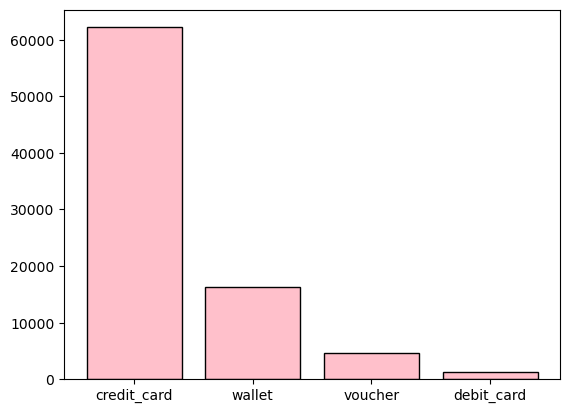

In [77]:
plt.bar(payments['payment_type'].value_counts().index, payments['payment_type'].value_counts(), color='pink', edgecolor='black')
plt.show()

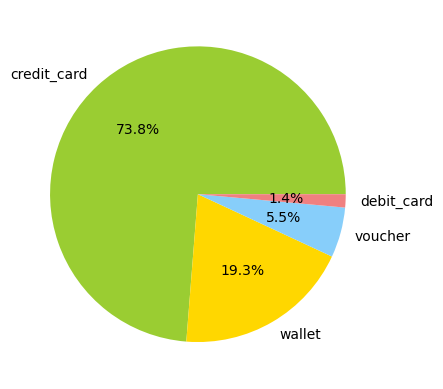

In [95]:
plt.pie(payments['payment_type'].value_counts(), labels=payments['payment_type'].value_counts().index, autopct='%1.1f%%', colors=['yellowgreen', 'gold', 'lightskyblue', 'lightcoral'])
plt.show()

**This implies that:**
- Credit card is the most preferred payment type, where about 3/4th of the payments are done through credit card. This preference shows a trust, popularity and availability of credit card facilities. This may also be due to the installment based payments too.
- Second most preferred option for payments is the Digital Wallet with 19.3% payments, indicating a good amount of adoption. This suggests that faster and easier payments are also being preferred, and this number may increase in the future with increasing adoption.
- Vouchers and debit cards get less than 7% of all payments, shows that, debit based and pre-paid purchases (for vouchers) is limited, possibly due to flexibility offered by digital wallets & credit-cards. Voucher usage being low suggests that, vouchers can be used for marketing and customer retention, but need to be more popularised.

#### **3.2 Installment Patterns** <a id="topic-3-2"></a>

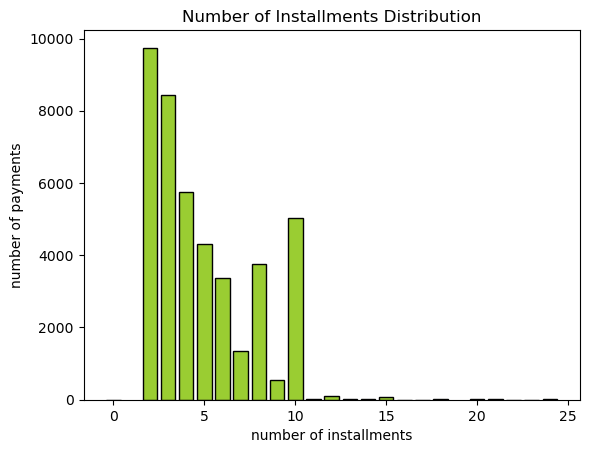

In [104]:
payment_installments_not_1 = payments['payment_installments'].value_counts().drop(1)
plt.bar(payment_installments_not_1.index, payment_installments_not_1, color='yellowgreen', edgecolor='black')
plt.xlabel('number of installments')
plt.ylabel('number of payments')
plt.title('Number of Installments Distribution')
plt.show()

In [124]:
payments['payment_installments'].value_counts().sort_values()

payment_installments
22        1
23        1
0         3
17        6
16        6
14        9
21        9
13       15
20       16
11       18
24       23
18       26
15       68
12      116
9       534
7      1338
6      3368
8      3753
5      4304
10     5024
4      5741
3      8442
2      9745
1     41836
Name: count, dtype: int64

In [125]:
payments['payment_installments'].value_counts().drop(1).sum()

42566

In [120]:
payments['payment_installments'].value_counts().drop([1,2,3,4,5,6,10,12,15,20,24]).sum()

5719

In [115]:
payments[payments['payment_type'] == 'credit_card']['payment_installments'].describe()

count    62247.000000
mean         3.668096
std          2.956340
min          0.000000
25%          1.000000
50%          3.000000
75%          5.000000
max         24.000000
Name: payment_installments, dtype: float64

In [114]:
payments[payments['payment_type'] != 'credit_card']['payment_installments'].describe()

count    22155.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: payment_installments, dtype: float64

**This implies that:**
- The number of payments done with installments is 42566 (50.4 % of total payments), suggesting that about half of the payments are done using installments. Out of which 2 installment payments are 9745 (about 22.3 % of installment payments & 12% of total payments).
- The trend in the number of installments with number of payments/transactions, goes down normally from 2 installments onwards steadily upto 5-6 installments.
- Then number of installments like 8, 10, 12, 15, 20 and 24 hike, being favorable and simple options to choose, as 10, 15 and 20 are multiple of 5s simple to choose, and 12 & 24 allows an installment every month of one or two years, another favorable option.
- Odd numbers in number of installments appear rarely appear in payments, where just 5719 out of 84402 (approx. 6.8%) have these odd number of installments.
- Also, the number of installments in all payments other than credit card payments is one (1), this means that payment in installments option should only be available with credit cards. Also, we get that options for any customizable number of installments is available and, installments are allowed to be no more than 2 years.

#### **3.3 Installments Vs. Payment Values** <a id="topic-3-3"></a>

- trying regression line to get correlation.
- Mean price vs installment type bar plot.
- and something

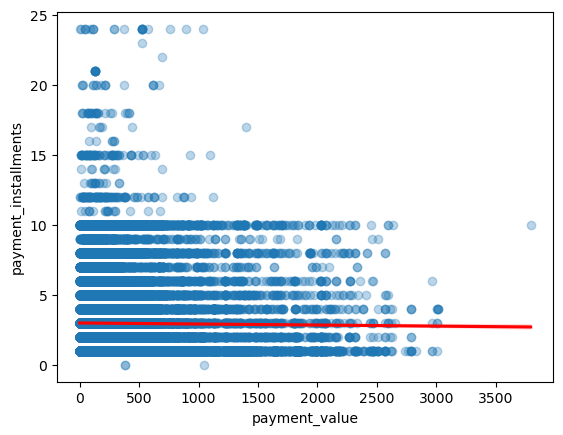

In [131]:
sns.regplot(data=payments, x='payment_value', y='payment_installments', scatter_kws={'alpha':0.3}, line_kws={'color': 'red'})
plt.show()

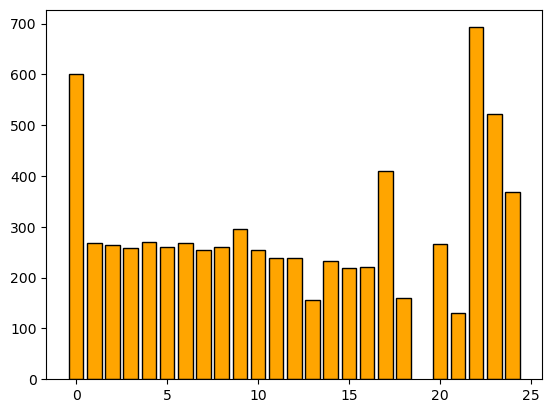

In [134]:
price_by_installments = payments.groupby('payment_installments')['payment_value'].mean()
plt.bar(price_by_installments.index, price_by_installments.values, color='orange', edgecolor='black')
plt.show()

**This implies that:**

- The number of installments have close to none correlation with payment value, most likely due to cultural normalization of usage of installment payments regardless of order size in Brazil.
- Most installment ranges have a similar average payment value, indicating normalized customer behavior in using installment payments in low to mid value products too.
- A hike in mean payment value occurs at 16 and 21–24 installments, indicating high number of installments for the high value products.
- Giving minimal to zero-interest on high-value products can get more engagement and align with customer behavior for products with a higher cost.
- This behavior also opens an opportunity for targeted offers on installment payments, to those customers who are more likely to go with installment payments.


This is the source for confirming this nature in Brazilian ecommerce market:
- https://www.novatradebrasil.com/en/e-commerce-payment-methods-in-brazil/
- https://www.adyen.com/payment-methods-guides/latin-america/brazil
- https://blog.international.pagseguro.com/en/why-installments-boost-e-commerce-in-brazil

---
#### **3.4 Payment Value Distribution** <a id="topic-3-4"></a>

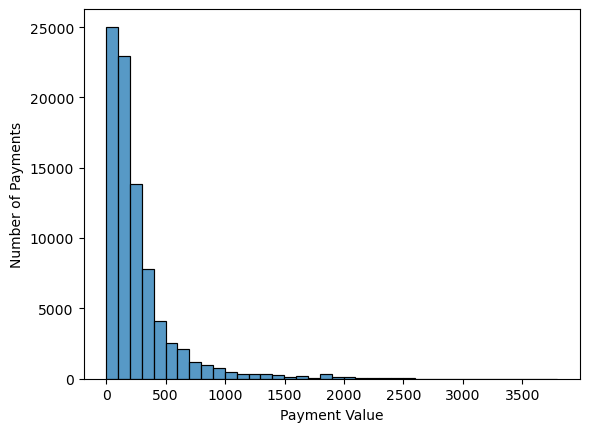

In [187]:
sns.histplot(payments['payment_value'], binwidth=100)
plt.ylabel('Number of Payments')
plt.xlabel('Payment Value')
plt.show()

In [167]:
len(payments[payments['payment_value'] > 500])

10592

In [174]:
len(payments[payments['payment_value'] > 1000])

3024

In [177]:
len(payments[payments['payment_value'] > 2000])

394

**This implies that:**

- Most of the payments have payment value less than 500 (about 87.5 %), this suggests that most products along with logistics cost exists in this range, implying that this range is the most accessible to customers.
- These prices are preferred among customers, suggesting these prices during sales/events like Black Friday etc, higher priced items be placed in this range, to get more attraction and engagement.
- About 3.5 % (3024) of these payments are valued over 1000, and just 0.4 % of the payments are valued over 2000. This suggests that high value payments are rare and require better financing options like minimal to zero interest in installment payments and promotional strategies to make them more frequent.
---

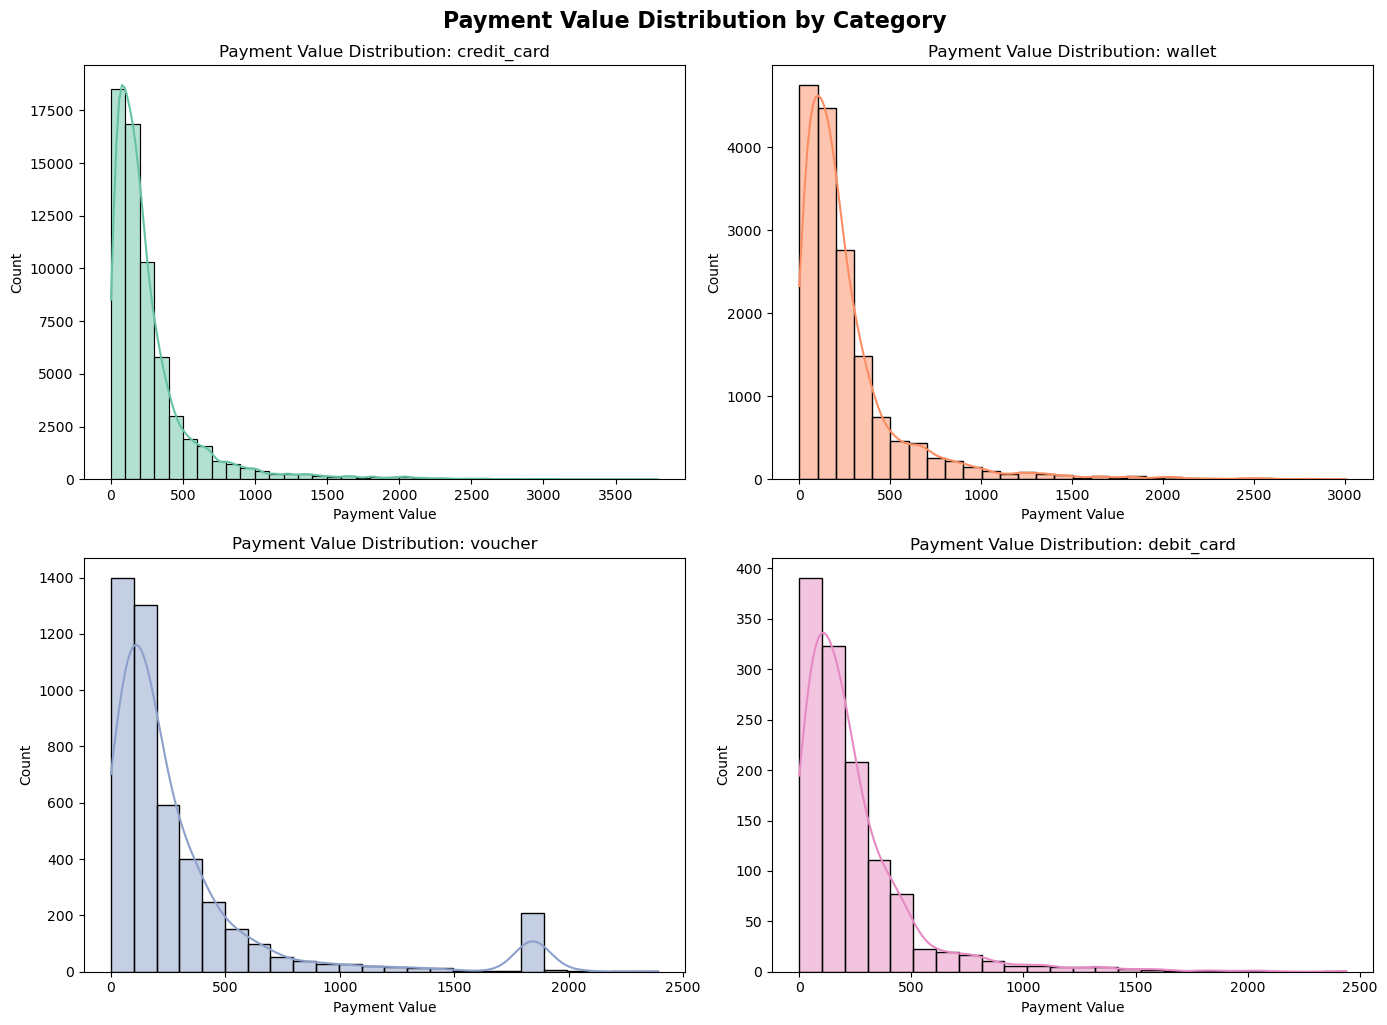

In [189]:
payment_types = payments['payment_type'].unique()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten() # making it iterable cuz its 2d array

for i, p_type in enumerate(payment_types):
    sns.histplot(
        data=payments[payments['payment_type'] == p_type],
        x='payment_value',
        binwidth=100,
        kde=True,
        ax=axes[i],
        color=sns.color_palette('Set2')[i]
    )
    axes[i].set_title(f'Payment Value Distribution: {p_type}')
    axes[i].set_xlabel('Payment Value')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.suptitle('Payment Value Distribution by Category', fontweight='bold', fontsize=16, y=1.02)
plt.show()

**Checking the local peak in voucher payment values in the 1800 to 1900 range:**

In [192]:
payments[(payments['payment_type'] == 'voucher') & (payments['payment_value'].between(1800,1900))]['payment_value'].value_counts().head()

payment_value
1843.85    201
1817.54      4
1853.75      1
1806.68      1
Name: count, dtype: int64

**This implies that:**
- From the payment value distribution, we get that higher value payments are generally done through credit_cards & digital wallet.
- These distributions follow the similar trends, but the limits are different based on their scales, as credit cards and digital wallets are used more often. The general trend is that payments under 500 occupy most of payment volume, and decreases exponentially as the payment value increases.
- Based on Voucher's payment value distribution, it is observed that payment values between 1800 & 1900 has a local peak (hike), due to the high volume of vouchers priced at 1843.85 (201 out of 207 payments) most likely due to some promotional vouchers gifted by either some organization or the platfrom itself for promotion.

---
#### **3.5 Payments & Shipping Trends Over Time** <a id="topic-3-5"></a>

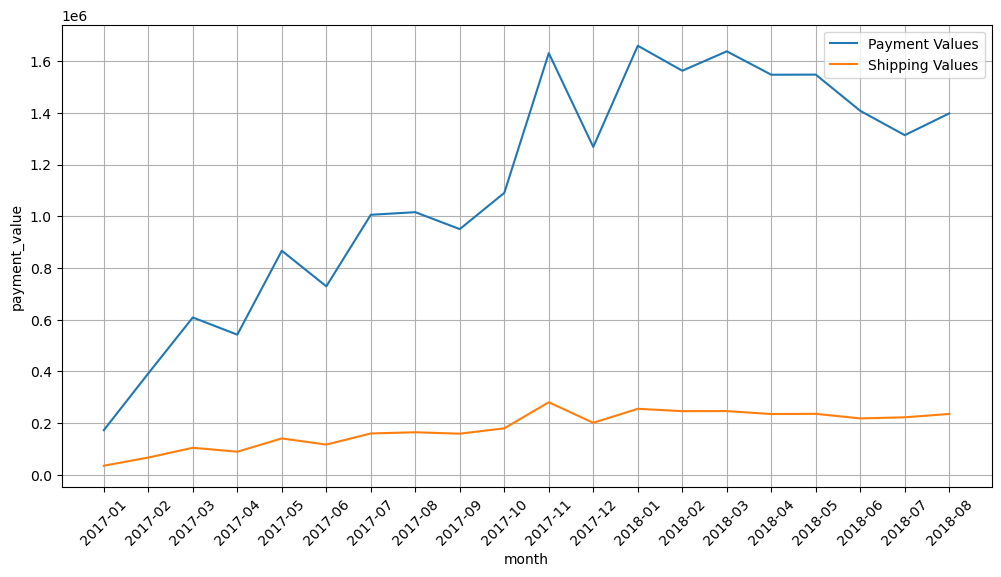

In [205]:
payments_and_dates = payments.merge(orders[['order_id', 'order_purchase_timestamp']], on='order_id')
payments_and_dates['month'] = payments_and_dates['order_purchase_timestamp'].dt.to_period('M').astype(str)
monthly_payments = payments_and_dates.groupby('month')['payment_value'].sum().reset_index()

items_and_dates = order_items.merge(orders[['order_id', 'order_purchase_timestamp']], on='order_id')
items_and_dates['month'] = items_and_dates['order_purchase_timestamp'].dt.to_period('M').astype(str)
monthly_shipping_charges = items_and_dates.groupby('month')['shipping_charges'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_payments, x='month', y='payment_value', label='Payment Values')
sns.lineplot(data=monthly_shipping_charges, x='month', y='shipping_charges', label='Shipping Values')
plt.xticks(rotation=45)
plt.grid()
plt.show()

**This implies that:**
- This ***line plot for payment values*** shows a **trend that is very similar** to the **trend in number of orders throughout months**.
- The line plot clearly shows a big spike in payment values around November 2017 (around 1.5 times the last month), followed by a small dip in December and then **consistently high payment values through early 2018**, which was followed by a slow decrease in payment values.
- This suggests a surge in payment values during **Brazil’s festive season & Carnival** and dry/summer season, which is during January to March. Also, the November spike could be the result of **Black Friday**, and upcoming holidays like **Christmas & New Year**.
- The **slow decrease** in payment values can be **due to rainy season**, as logistics are affected. The trend points to a strong seasonal influence, possibly tied to local holidays, marketing pushes, or year-end shopping behaviors.

- The ***line plot for shipping charges*** follows a slightly similar trend as payment values. It can be observed that the shipping charges have a **mild positive correlation** to the payment values.
- The shipping charges in the beginning of the year 2017 were closer to the total payment values, going forward this **gap in total payment value and shipping charges increases**, suggesting that the shipping charges got lowered as time goes by, this indicates that the platform logistics got better over time, as the revenue increased.

---
#### **3.6 Shipping Ratio Distribution** <a id="topic-3-6"></a>

In [206]:
order_items.head()

,order_id,product_id,seller_id,price,shipping_charges,shipping_price_ratio
0,Axfy13Hk4PIk,90K0C1fIyQUf,ZWM05J9LcBSF,223.51,84.65,0.378730
1,v6px92oS8cLG,qejhpMGGVcsl,IjlpYfhUbRQs,170.80,23.79,0.139286
2,Ulpf9skrhjfm,qUS5d2pEAyxJ,77p2EYxcM9MD,64.40,17.38,0.269876
3,bwJVWupf2keN,639iGvMyv0De,jWzS0ayv9TGf,264.50,30.72,0.116144
4,Dd0QnrMk9Cj5,1lycYGcsic2F,l1pYW6GBnPMr,779.90,30.66,0.039313


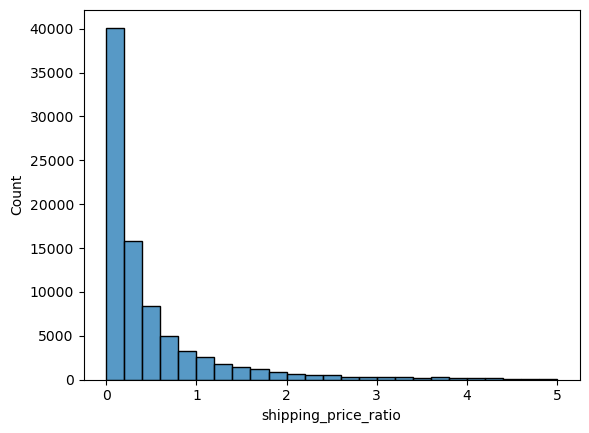

In [212]:
sns.histplot(data=order_items, x='shipping_price_ratio', binwidth=0.2)
plt.show()

**This implies that:**
- Most of the orders (about 90 %) have shipping_price_ratio less than 1, while around 75 % of the orders have it less than 0.4. This implies that, in general, maximum orders have low shippnig charges (lower than the price of product).
- In some cases, the shipping charges are more than the price of the product (shipping_price_ratio > 1), this is likely due to orders from remote places like in the Northern & Amazon regions of Brazil.

---
#### **3.7 Shipping Charges by Location** <a id="topic-3-7"></a>
will try on it 

---
## **4. Conclusion & Insights Recap** <a id="topic-4"></a>

---
## **5. Recommendations based on Insights** <a id="topic-5"></a>
